# Model Comparison & Export for Unity

Compare all trained models, select the best one, and export to ONNX format for Unity Barracuda inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_DIR = "../../datasets/processed"
MODEL_DIR = "../../models"
EXPORT_DIR = "../../models/unity_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Load results
with open(f"{MODEL_DIR}/tree_results.json") as f:
    all_results = json.load(f)

print(f"Loaded results for {len(all_results)} models: {list(all_results.keys())}")

Loaded results for 3 models: ['RandomForest', 'XGBoost', 'LightGBM']


## 1. Full Comparison Table

In [2]:
rows = []
for name, res in all_results.items():
    for target in ["GHR", "DLI"]:
        rows.append({
            "Model": name, "Target": target,
            "RMSE": round(res[target]["RMSE"], 4),
            "MAE": round(res[target]["MAE"], 4),
            "R²": round(res[target]["R2"], 6),
            "MAPE(%)": round(res[target]["MAPE"], 2),
            "Train(s)": round(res["train_time"], 1),
            "Inference(ms)": round(res["inference_ms"], 2)
        })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

       Model Target     RMSE      MAE       R²  MAPE(%)  Train(s)  Inference(ms)
RandomForest    GHR 232.7505 112.1630 0.944959    18.62       1.4          16.41
RandomForest    DLI   1.6908   0.8148 0.944959    18.62       1.4          16.41
     XGBoost    GHR  82.6144  49.8768 0.993066    12.67       2.2           3.51
     XGBoost    DLI   0.6038   0.3660 0.992981    12.78       2.2           3.51
    LightGBM    GHR 165.1271 100.2085 0.972296    24.10       3.1           0.88
    LightGBM    DLI   1.2020   0.7292 0.972182    24.15       3.1           0.88


## 2. Visual Comparison

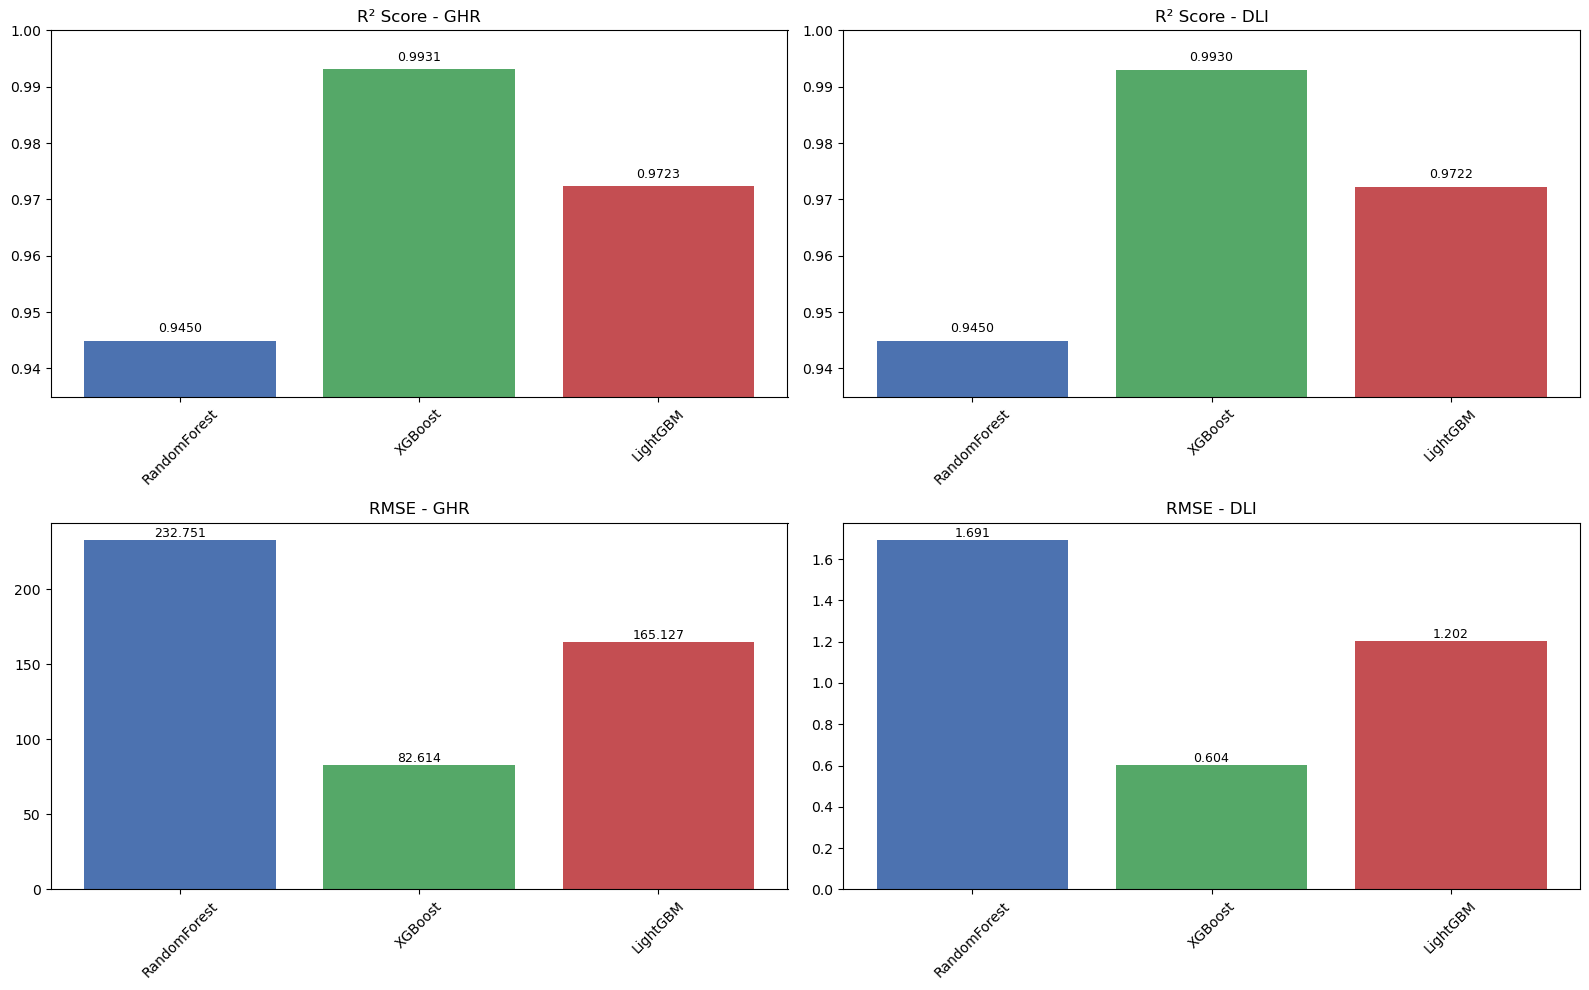

In [3]:
model_names = list(all_results.keys())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# R² comparison
for i, target in enumerate(["GHR", "DLI"]):
    r2_vals = [all_results[m][target]["R2"] for m in model_names]
    bars = axes[0, i].bar(model_names, r2_vals, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"])
    axes[0, i].set_title(f"R² Score - {target}")
    axes[0, i].set_ylim(min(r2_vals) - 0.01, 1.0)
    axes[0, i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, r2_vals):
        axes[0, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# RMSE comparison
for i, target in enumerate(["GHR", "DLI"]):
    rmse_vals = [all_results[m][target]["RMSE"] for m in model_names]
    bars = axes[1, i].bar(model_names, rmse_vals, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"])
    axes[1, i].set_title(f"RMSE - {target}")
    axes[1, i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, rmse_vals):
        axes[1, i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Select Best Model

In [4]:
# Rank by average R² across both targets
rankings = {}
for name, res in all_results.items():
    avg_r2 = (res["GHR"]["R2"] + res["DLI"]["R2"]) / 2
    avg_rmse = (res["GHR"]["RMSE"] + res["DLI"]["RMSE"]) / 2
    rankings[name] = {"avg_R2": avg_r2, "avg_RMSE": avg_rmse, "inference_ms": res["inference_ms"]}

ranking_df = pd.DataFrame(rankings).T.sort_values("avg_R2", ascending=False)
print("Model Rankings (by avg R²):\n")
print(ranking_df.to_string())

best_model_name = ranking_df.index[0]
print(f"\n>>> Best model: {best_model_name} (avg R²={ranking_df.iloc[0]['avg_R2']:.6f})")

Model Rankings (by avg R²):

                avg_R2    avg_RMSE  inference_ms
XGBoost       0.993023   41.609079      3.514314
LightGBM      0.972239   83.164578      0.883985
RandomForest  0.944959  117.220671     16.407275

>>> Best model: XGBoost (avg R²=0.993023)


## 4. Prediction vs Actual (Best Model)

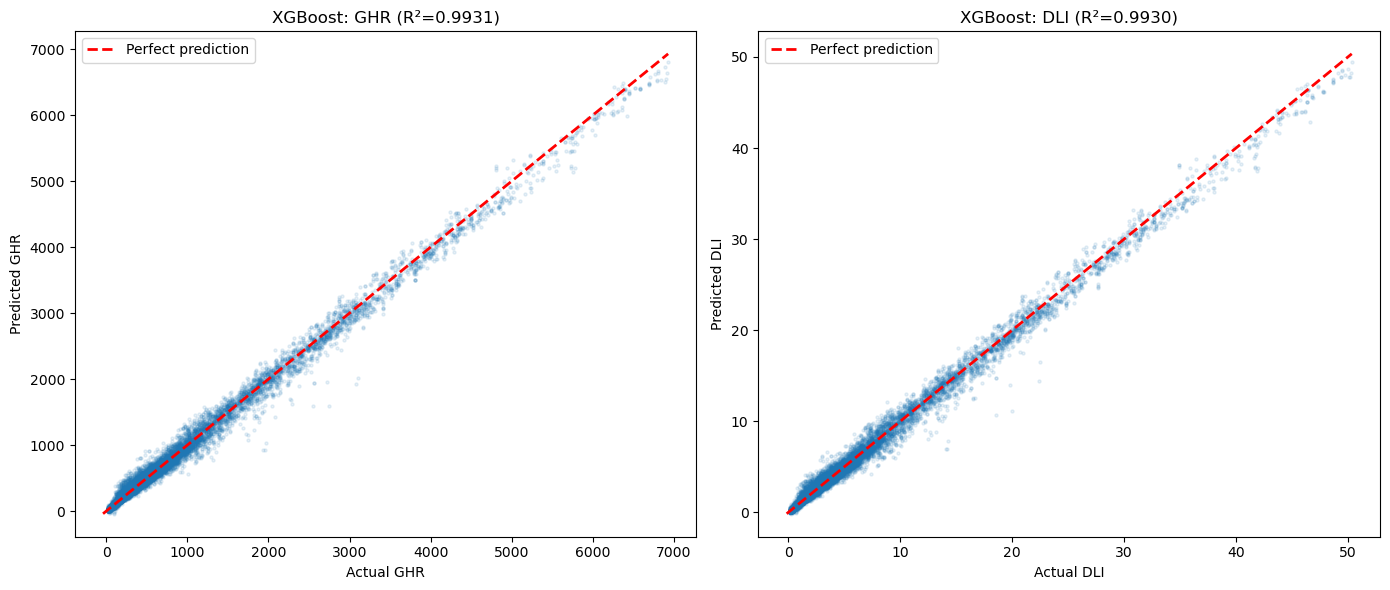

In [5]:
# Load best model and test data
X_test = pd.read_csv(f"{DATA_DIR}/X_test_tree.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv")

model_files = {
    "RandomForest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl",
    "LightGBM": "lightgbm.pkl",
}
best_model = joblib.load(f"{MODEL_DIR}/{model_files[best_model_name]}")
y_pred = best_model.predict(X_test)

# Scatter: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, target in enumerate(["GHR", "DLI"]):
    yt = y_test.iloc[:, i].values
    yp = y_pred[:, i]
    
    axes[i].scatter(yt, yp, alpha=0.1, s=5)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    axes[i].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
    axes[i].set_xlabel(f"Actual {target}")
    axes[i].set_ylabel(f"Predicted {target}")
    axes[i].set_title(f"{best_model_name}: {target} (R²={all_results[best_model_name][target]['R2']:.4f})")
    axes[i].legend()

plt.tight_layout()
plt.show()

## 5. Export to ONNX for Unity

Export the best model to ONNX format for Unity Barracuda inference.  
Also export a JSON config with feature names, scaler params, and encoding maps so Unity knows how to prepare inputs.

In [6]:
import onnxruntime as ort
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

n_features = X_test.shape[1]
feature_names = list(X_test.columns)

# onnxmltools requires feature names as 'f0', 'f1', ...
# We remap feature names on the booster before converting
onnx_paths = {}
for idx, target in enumerate(["GHR", "DLI"]):
    estimator = best_model.estimators_[idx]
    # Temporarily rename features for ONNX conversion
    booster = estimator.get_booster()
    booster.feature_names = [f"f{i}" for i in range(n_features)]
    
    initial_type = [("input", FloatTensorType([None, n_features]))]
    onnx_model = convert_xgboost(estimator, initial_types=initial_type)
    
    # Restore original feature names
    booster.feature_names = feature_names
    
    path = f"{EXPORT_DIR}/daylight_{target.lower()}.onnx"
    with open(path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    onnx_paths[target] = path
    print(f"  {target} ONNX saved: {path} ({os.path.getsize(path) / 1024:.1f} KB)")

# Verify ONNX inference matches sklearn
print("\nVerification:")
test_input = X_test.iloc[:5].values.astype(np.float32)
sklearn_pred = best_model.predict(test_input)

for idx, target in enumerate(["GHR", "DLI"]):
    sess = ort.InferenceSession(onnx_paths[target])
    onnx_pred = sess.run(None, {"input": test_input})[0].flatten()
    diff = np.max(np.abs(onnx_pred - sklearn_pred[:, idx]))
    print(f"  {target}: max diff = {diff:.8f} ({'OK' if diff < 0.01 else 'CHECK'})")

  GHR ONNX saved: ../../models/unity_export/daylight_ghr.onnx (6300.1 KB)


  DLI ONNX saved: ../../models/unity_export/daylight_dli.onnx (6008.3 KB)

Verification:
  GHR: max diff = 0.00058365 (OK)
  DLI: max diff = 0.00000191 (OK)


## 6. Unity Config (feature mapping & scaler params)

In [7]:
# Build Unity config JSON
label_encoders = joblib.load(f"{DATA_DIR}/label_encoders.pkl")

unity_config = {
    "model_name": best_model_name,
    "model_files": {"GHR": "daylight_ghr.onnx", "DLI": "daylight_dli.onnx"},
    "feature_names": feature_names,
    "output_names": ["GHR", "DLI"],
    "label_encodings": {
        col: dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist()))
        for col, le in label_encoders.items()
    },
    "one_hot_order": {
        "Building": ["Architecture", "CEB", "Housing"],
        "Orientation": ["E", "N", "NE", "NW", "S", "SE", "W"],
        "Level": ["G", "M", "U"],
    },
    "user_parameters": {
        "Day_of_Year": {"type": "int", "min": 1, "max": 365, "description": "Day of year (1-365)"},
        "Tree_Width_m": {"type": "int", "options": [3, 6], "description": "Tree canopy width in meters"},
        "Tree_Present": {"type": "bool", "description": "Whether trees are present (true/false)"},
        "Window_Transmittance": {"type": "float", "options": [0.1, 0.6, 0.9], "description": "Window transmittance percentage"},
        "Building": {"type": "string", "options": ["Architecture", "CEB", "Housing"], "description": "Building type"},
        "Orientation": {"type": "string", "options": ["N", "NE", "NW", "E", "S", "SE", "W"], "description": "Facade orientation"},
        "Level": {"type": "string", "options": ["G", "M", "U"], "description": "Floor level (G=Ground, M=Middle, U=Upper)"},
        "WWR": {"type": "float", "min": 0.0, "max": 1.0, "description": "Window-to-Wall Ratio"},
    },
}

config_path = f"{EXPORT_DIR}/unity_config.json"
with open(config_path, "w") as f:
    json.dump(unity_config, f, indent=2)

print(f"Unity config saved: {config_path}")
print(f"\nUser-adjustable parameters in Unity:")
for param, info in unity_config["user_parameters"].items():
    print(f"  {param}: {info['description']}")

Unity config saved: ../../models/unity_export/unity_config.json

User-adjustable parameters in Unity:
  Day_of_Year: Day of year (1-365)
  Tree_Width_m: Tree canopy width in meters
  Tree_Present: Whether trees are present (true/false)
  Window_Transmittance: Window transmittance percentage
  Building: Building type
  Orientation: Facade orientation
  Level: Floor level (G=Ground, M=Middle, U=Upper)
  WWR: Window-to-Wall Ratio


## 7. End-to-End Unity Inference Example

Simulates what the Unity client will do: take user parameters → encode → predict.

In [8]:
def unity_predict(onnx_paths, user_input):
    """
    Simulate Unity-side inference.
    user_input: dict with user-adjustable params.
    """
    day = user_input["Day_of_Year"]
    
    # Cyclical encoding
    day_sin = np.sin(2 * np.pi * day / 365)
    day_cos = np.cos(2 * np.pi * day / 365)
    
    # Season
    if day <= 59 or day >= 335:
        season_num = 0
    elif 60 <= day <= 151:
        season_num = 1
    elif 152 <= day <= 243:
        season_num = 2
    else:
        season_num = 3
    
    season_sin = np.sin(2 * np.pi * season_num / 4)
    season_cos = np.cos(2 * np.pi * season_num / 4)
    
    # Interaction features
    tree_present_int = int(user_input["Tree_Present"])
    effective_trans = user_input["Window_Transmittance"] * (1 - tree_present_int * 0.9)
    wwr_x_trans = user_input["WWR"] * user_input["Window_Transmittance"]
    tree_effect = user_input["Tree_Width_m"] * tree_present_int
    
    # One-hot encode
    buildings = ["Architecture", "CEB", "Housing"]
    orientations = ["E", "N", "NE", "NW", "S", "SE", "W"]
    levels = ["G", "M", "U"]
    
    bld_ohe = [1 if b == user_input["Building"] else 0 for b in buildings]
    ori_ohe = [1 if o == user_input["Orientation"] else 0 for o in orientations]
    lvl_ohe = [1 if l == user_input["Level"] else 0 for l in levels]
    
    features = np.array([[
        day, tree_present_int, user_input["Window_Transmittance"],
        user_input["WWR"], user_input["Tree_Width_m"],
        day_sin, day_cos, season_sin, season_cos,
        effective_trans, wwr_x_trans, tree_effect,
        *bld_ohe, *ori_ohe, *lvl_ohe
    ]], dtype=np.float32)
    
    # Run both ONNX models
    results = {}
    for target, path in onnx_paths.items():
        sess = ort.InferenceSession(path)
        pred = sess.run(None, {"input": features})[0].flatten()[0]
        results[target] = float(pred)
    
    return results


# Test with example input
example = {
    "Day_of_Year": 180,
    "Tree_Width_m": 3,
    "Tree_Present": True,
    "Window_Transmittance": 0.6,
    "Building": "CEB",
    "Orientation": "NE",
    "Level": "U",
    "WWR": 0.3
}

result = unity_predict(onnx_paths, example)
print(f"Example Unity prediction:")
print(f"  Input: {example}")
print(f"  Output: GHR={result['GHR']:.2f}, DLI={result['DLI']:.4f}")

# Seasonal comparison
print("\nSeasonal comparison (CEB, NE, Upper, WWR=0.3, Trees=True, 3m, Trans=0.6):")
for day, label in [(15, "Winter"), (100, "Spring"), (180, "Summer"), (280, "Autumn")]:
    ex = {**example, "Day_of_Year": day}
    r = unity_predict(onnx_paths, ex)
    print(f"  {label} (day {day}): GHR={r['GHR']:.1f}, DLI={r['DLI']:.3f}")

Example Unity prediction:
  Input: {'Day_of_Year': 180, 'Tree_Width_m': 3, 'Tree_Present': True, 'Window_Transmittance': 0.6, 'Building': 'CEB', 'Orientation': 'NE', 'Level': 'U', 'WWR': 0.3}
  Output: GHR=276.05, DLI=2.1881

Seasonal comparison (CEB, NE, Upper, WWR=0.3, Trees=True, 3m, Trans=0.6):


  Winter (day 15): GHR=36.4, DLI=0.253


  Spring (day 100): GHR=141.4, DLI=0.803


  Summer (day 180): GHR=276.1, DLI=2.188


  Autumn (day 280): GHR=326.3, DLI=2.334


## Summary

**Best Model: XGBoost** (R² ≈ 0.993 for both GHR and DLI)

**Exported for Unity (`models/unity_export/`):**
- `daylight_ghr.onnx` — XGBoost model for GHR prediction
- `daylight_dli.onnx` — XGBoost model for DLI prediction
- `unity_config.json` — feature names, one-hot encoding order, parameter definitions

**Unity integration:** Load both ONNX models with Barracuda, encode user inputs using `unity_config.json`, run inference on each model, display results.